# Benchmark: C3794 Two-Cavity Module vs CST Studio Suite

This benchmark computes the S- and Z-parameters of a two-cavity module and compares them with
CST Studio Suite over 0.1–1.0 GHz. Each cavity is a C3794 cavity with a fundamental power
coupler (FPC) and a higher-order-mode (HOM) coupler, both coaxial.

The module is built the reduced-order way. One cavity is solved at full order and reduced to a
small model, and two copies of that model are coupled through the beam pipe. The CST reference
meshes and solves the whole module as one problem.

**Downloads**

| File | Contents |
|---|---|
| [c3794_4hc_1fpc_w_TEM.stp](https://dark-elektron.github.io/cavsim3d/example_models/c3794/c3794_4hc_1fpc_w_TEM.stp) | Geometry of one cavity (STEP, exported from CST, millimetres) |
| [E_C3794_1HC_1FPC_ports_w_TEM_2cav_module.cst](https://dark-elektron.github.io/cavsim3d/example_models/c3794/E_C3794_1HC_1FPC_ports_w_TEM_2cav_module.cst) | CST Studio Suite project of the two-cavity reference |
| [c3794_2cav_module.npz](https://dark-elektron.github.io/cavsim3d/example_models/c3794/c3794_2cav_module.npz) | The results shown on this page, from both codes on the same 1001-point grid |

The page plots the saved results. To reproduce them, put the downloads in one folder, set
`DATA_DIR` to it and set `RUN_SIMULATION = True` below. To check the reference, solve the CST
project and set `CST_PROJECT` to its folder.

## The model

The STEP file contains five solids: the vacuum region, the ceramic window of the FPC
($\varepsilon_r = 10$) and three metal parts. The metal parts are treated as perfect conductors
and removed from the computational domain. Each cavity has four ports: the two ends of the
150 mm-radius beam pipe, and the FPC and HOM coaxial lines.

Several modes propagate in the beam pipe within the band:

| Beam-pipe mode | Cutoff |
|---|---|
| TE$_{11}$ (two polarisations) | 585.7 MHz |
| TM$_{01}$ | 765.0 MHz |
| TE$_{21}$ (two polarisations) | 971.5 MHz |

Each beam-pipe port therefore carries all five modes, and each coaxial port carries its TEM mode.
A port mode that is left out sees a magnetic wall at the port. At the junction between two
cavities that mode would be reflected instead of passing through, so the junction needs every
mode that can propagate.

| Setting | Value |
|---|---|
| Element order | 2 |
| Mesh size bound (`maxh`) | 0.03 m ($\lambda/10$ at 1 GHz); 0.05 m on the port faces |
| Full-order unknowns per cavity | 1,135,086 |
| Snapshots (full-order solves) | 50, spread over 0.1–1.0 GHz |
| POD tolerance | $10^{-8}$ |
| Frequency sweep | 1001 points |

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Folder with the downloads above (their place in the repository)
DATA_DIR = Path("../../example_models/c3794")
STEP_FILE = DATA_DIR / "c3794_4hc_1fpc_w_TEM.stp"
SAVED = np.load(DATA_DIR / "c3794_2cav_module.npz")

# True reruns the workflow below. The full-order solve of one cavity
# takes about 50 minutes and 25 GB of memory on a 16-core laptop
# (Intel Core Ultra 7 255H). False uses the saved results.
RUN_SIMULATION = False

# Optional: a solved CST project folder whose Export folder holds the
# ASCII S- and Z-parameter exports.
CST_PROJECT = None

## 1. Solve one cavity and reduce it

The cavity is meshed, solved at full order at 50 frequencies (the snapshots) and reduced by
proper orthogonal decomposition. `maxh` is in metres, NGSolve's unit. This step dominates the
cost, and it is done once: every module built afterwards reuses the saved reduced model.

In [2]:
from cavsim3d.core.em_project import EMProject

WORK = Path("./simulations")
BAND = dict(fmin=0.1, fmax=1.0)          # GHz
# five modes on each beam pipe, the TEM mode on each coaxial port
PORT_MODES = {"port1": 5, "port2": 5, "default": 1}
MATERIALS = {"lh4*": "PEC", "dh2*": "PEC", "solid": "PEC",  # metal
             "ceramic*": {"eps_r": 10},                     # FPC window
             "solid1*": {"eps_r": 1}}                       # vacuum

if RUN_SIMULATION:
    cavity = EMProject(name="c3794_cavity", base_dir=str(WORK),
                       overwrite=True)
    geo = cavity.create_importer(str(STEP_FILE), unit="mm",
                                 auto_build=False)
    geo.set_materials(MATERIALS)
    geo.build()
    geo.set_local_mesh_refinement("port*", 0.05)       # port faces
    geo.generate_mesh(maxh=0.03, curvaturesafety=1.5)  # lambda/10
    cavity.geometry = geo

    cavity.fds.solve(config=dict(**BAND, nsamples=50, order=2,
                                 solver_type="direct",
                                 nportmodes=PORT_MODES))
    cavity.fds.fom.reduce(tol=1e-8)
    cavity.save()

## 2. Couple two cavities

The saved cavity is imported twice. The assembly joins the lower beam-pipe end of the first copy
to the upper end of the second, and the two reduced models are coupled through the five
beam-pipe modes at that junction. Only the coupled system, a few hundred unknowns, is solved at
the 1001 sweep points.

In [3]:
if RUN_SIMULATION:
    module = EMProject(name="c3794_module2", base_dir=str(WORK),
                       overwrite=True)
    asm = module.create_assembly(main_axis="Z")
    asm.add("cavity", module.fds.import_model(cavity.project_path), n=2)
    module.fds.solve(config=dict(**BAND, nsamples=10, order=2,
                                 nportmodes=PORT_MODES))
    concat = module.fds.foms.reduce(tol=1e-8).concatenate()
    concat.solve(config=dict(**BAND, nsamples=1001,
                             solver_type="direct"))
    print(f"coupled system: {concat.A_coupled.shape[0]} unknowns")

## 3. Ports and modes in the two models

The two models number their ports differently:

| Port here | Location | CST port |
|---|---|---|
| 1 | beam pipe, top ($z^+$) | 1 |
| 2 | FPC, upper cavity | 3 |
| 3 | HOM coupler, upper cavity | 4 |
| 4 | beam pipe, bottom ($z^-$) | 2 |
| 5 | FPC, lower cavity | 6 |
| 6 | HOM coupler, lower cavity | 7 |

They also define different modes at the beam pipes. The CST model defines three modes at its
bottom port (TE$_{11}$ in both polarisations, and TM$_{01}$) and one at its top port
(TE$_{11}$). CST's first TE$_{11}$ mode is the polarisation numbered second here.

To compare like with like, the coupled model is expressed in CST's port definition. The modes
are relabelled, and every mode that CST does not define is closed with an open circuit
($I = 0$), which is how a port treats a mode it does not define. With pseudo-wave
S-parameters an open circuit reflects with $\Gamma = +1$, so keeping the modes $k$ and closing
the modes $d$ gives

$$
\mathbf{S}' = \mathbf{S}_{kk} + \mathbf{S}_{kd}\,(\mathbf{I} - \mathbf{S}_{dd})^{-1}\,\mathbf{S}_{dk},
\qquad \mathbf{Z}' = \mathbf{Z}_{kk} .
$$

In [4]:
# Compared port modes as port(mode), in CST's mode numbering
LABELS = ["1(1)", "2(1)", "3(1)", "4(1)", "4(2)", "4(3)", "5(1)", "6(1)"]
CST_LABELS = ["1(1)", "3(1)", "4(1)", "2(1)", "2(2)", "2(3)", "6(1)",
              "7(1)"]
# The two TE11 polarisations are numbered the other way round here
OUR_LABEL = {"1(1)": "1(2)", "4(1)": "4(2)", "4(2)": "4(1)"}


def to_matrix(d, rows, cols, excitation_first):
    # S/Z dictionary -> array [frequency, response, excitation].
    # cavsim3d keys name the excitation first, CST keys the response.
    def key(r, c):
        return c + r if excitation_first else r + c
    return np.stack([np.stack([np.asarray(d[key(r, c)]) for c in cols],
                              -1) for r in rows], -2)


def in_cst_port_definition(concat):
    # S and Z on CST's port modes; all other modes open-circuited
    keep = [OUR_LABEL.get(x, x) for x in LABELS]
    every = sorted({m for k in concat.S_dict if k != "frequencies"
                    for m in re.findall(r"\d+\(\d+\)", k)})
    drop = [x for x in every if x not in keep]

    def M(r, c):
        return to_matrix(concat.S_dict, r, c, excitation_first=True)

    S = M(keep, keep) + M(keep, drop) @ np.linalg.solve(
        np.eye(len(drop)) - M(drop, drop), M(drop, keep))
    Z = to_matrix(concat.Z_dict, keep, keep, excitation_first=True)
    return S, Z


freq = SAVED["frequency_GHz"]
S_cst, Z_cst = SAVED["S_cst"], SAVED["Z_cst"]
if RUN_SIMULATION:
    freq = np.asarray(concat.frequencies) / 1e9
    S, Z = in_cst_port_definition(concat)
else:
    S, Z = SAVED["S_ns50"], SAVED["Z_ns50"]
if CST_PROJECT is not None:
    from cavsim3d.analytical.cst_result import CSTResult
    cst = CSTResult(CST_PROJECT).interpolate_to(freq * 1e9)
    S_cst = to_matrix(cst.S_dict, CST_LABELS, CST_LABELS, False)
    Z_cst = to_matrix(cst.Z_dict, CST_LABELS, CST_LABELS, False)

print(f"{len(freq)} frequencies, {len(LABELS)} port modes compared")

1001 frequencies, 8 port modes compared


## 4. S-parameters

The fundamental mode of every port: TE$_{11}$ at the beam pipes and TEM at the couplers.
Entry $(i, j)$ is the response at port $i$ to an excitation at port $j$.

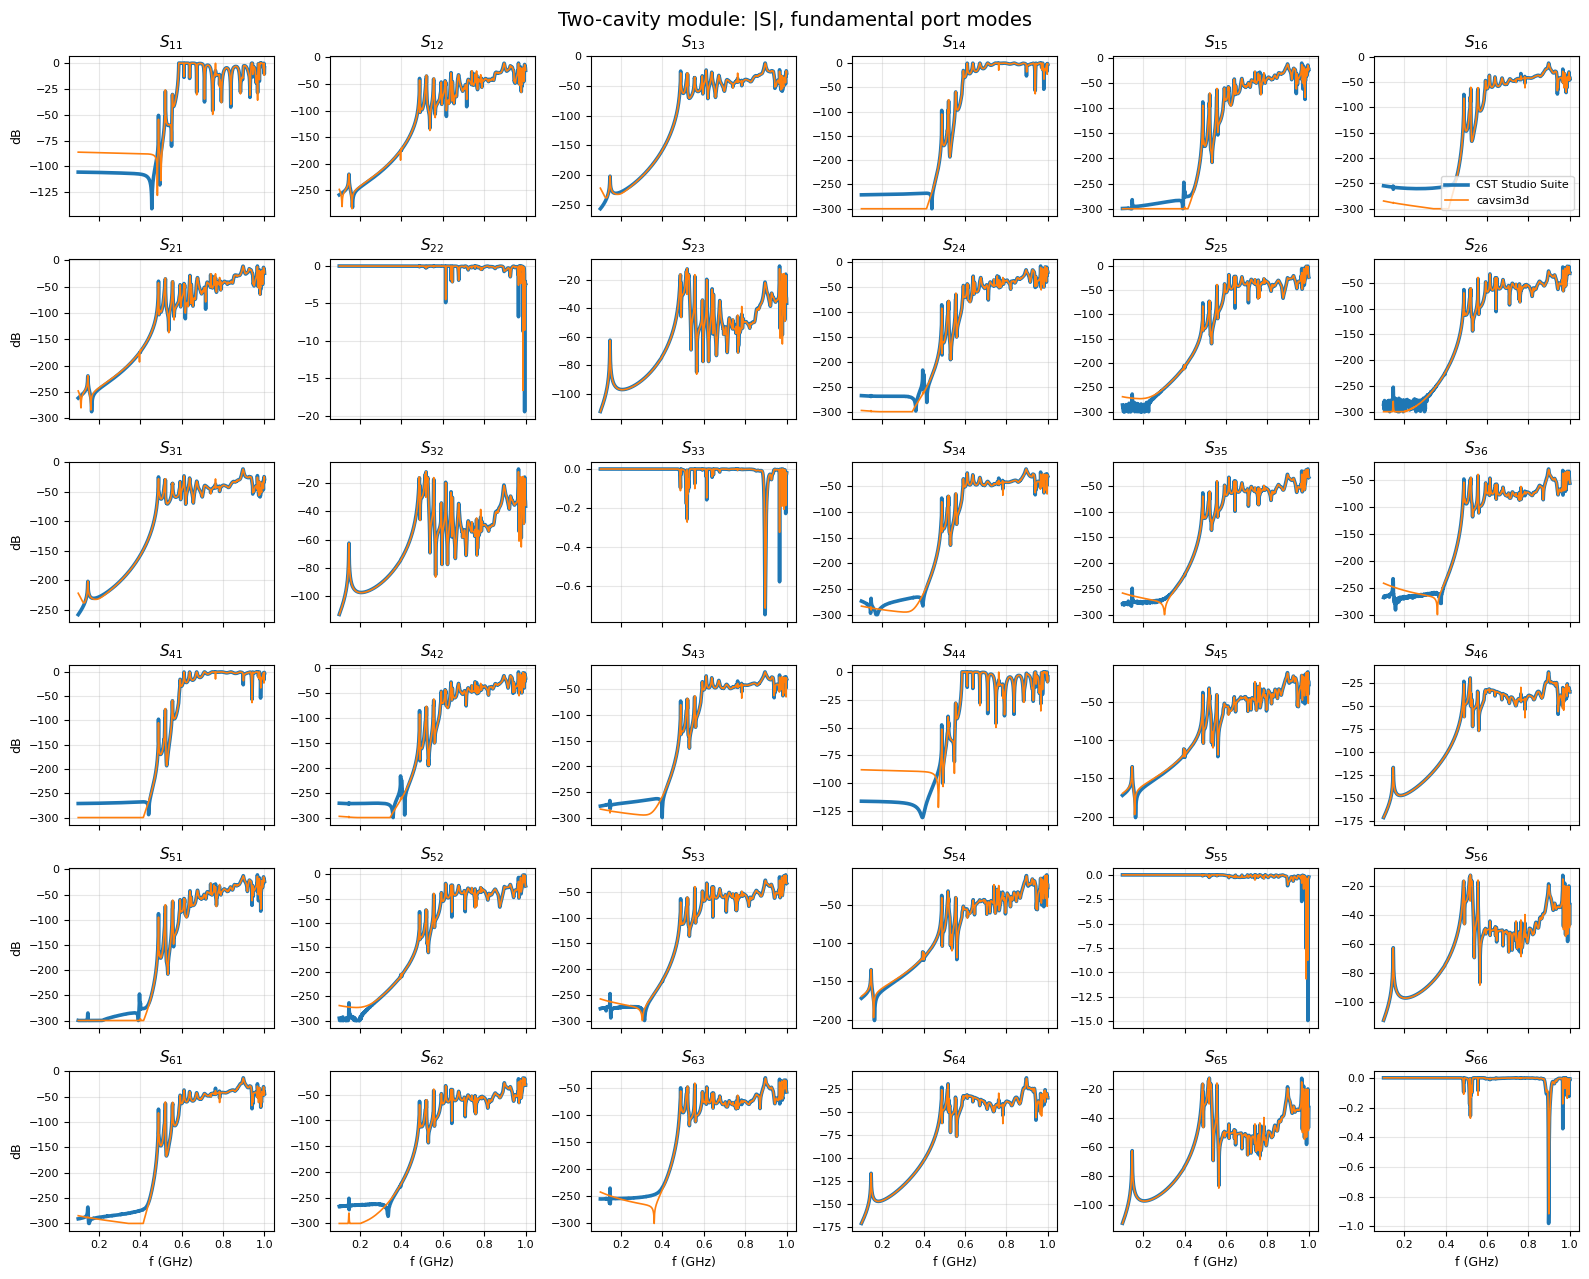

In [5]:
def db(x):
    return 20 * np.log10(np.maximum(np.abs(x), 1e-15))


MAIN = [0, 1, 2, 3, 6, 7]      # fundamental mode of each port
PORT_NO = [LABELS[i][0] for i in MAIN]


def matrix_plot(A, A_cst, name):
    n = len(MAIN)
    fig, axs = plt.subplots(n, n, figsize=(16, 13), sharex=True)
    for r, i in enumerate(MAIN):
        for c, j in enumerate(MAIN):
            ax = axs[r, c]
            ax.plot(freq, db(A_cst[:, i, j]), color="tab:blue", lw=2.6,
                    label="CST Studio Suite")
            ax.plot(freq, db(A[:, i, j]), color="tab:orange", lw=1.2,
                    label="cavsim3d")
            ax.set_title(f"${name}_{{{PORT_NO[r]}{PORT_NO[c]}}}$",
                         fontsize=11)
            ax.tick_params(labelsize=8)
            ax.grid(alpha=0.3)
            if c == 0:
                ax.set_ylabel("dB", fontsize=9)
            if r == n - 1:
                ax.set_xlabel("f (GHz)", fontsize=9)
    axs[0, -1].legend(loc="lower right", fontsize=8)
    fig.suptitle(f"Two-cavity module: |{name}|, fundamental port modes",
                 fontsize=14)
    fig.tight_layout()
    plt.show()


def detail_plot(pairs, A, A_cst, name="S"):
    fig, axs = plt.subplots(1, len(pairs), figsize=(16, 4.2))
    for ax, (i, j, title) in zip(axs, pairs):
        ax.plot(freq, db(A_cst[:, i, j]), color="tab:blue", lw=2.6,
                label="CST Studio Suite")
        ax.plot(freq, db(A[:, i, j]), color="tab:orange", lw=1.2,
                label="cavsim3d")
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("f (GHz)")
        ax.set_ylabel(f"|{name}| (dB)")
        ax.grid(alpha=0.3)
    axs[0].legend(fontsize=9)
    fig.tight_layout()
    plt.show()


matrix_plot(S, S_cst, "S")

A closer look at three entries: the FPC reflection of the upper cavity, the transmission from
the upper to the lower FPC, and the transmission through the whole module along the beam
pipe.

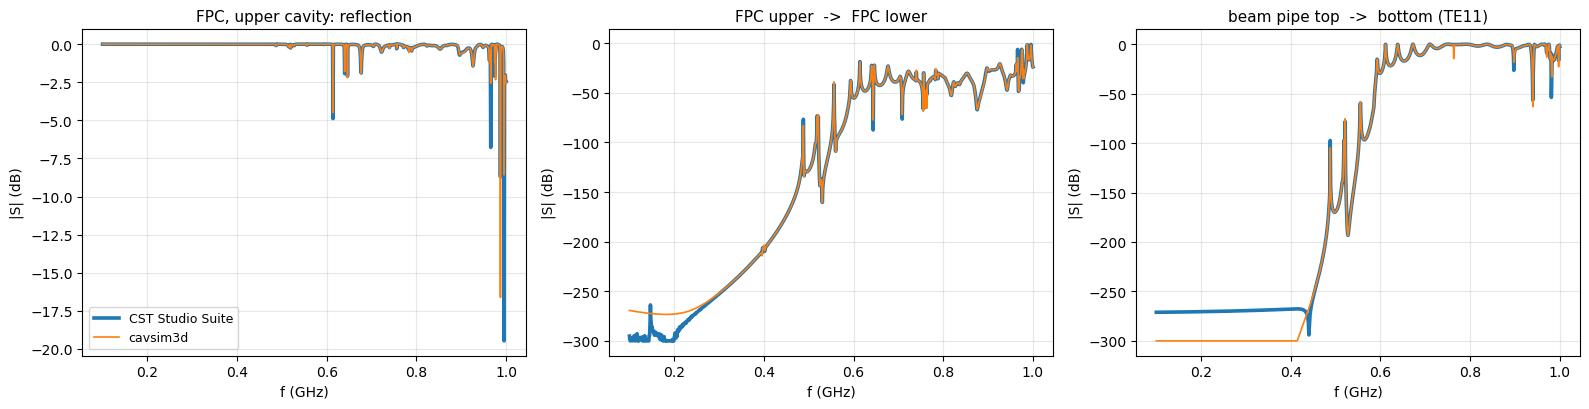

In [6]:
detail_plot([(1, 1, "FPC, upper cavity: reflection"),
             (6, 1, "FPC upper  ->  FPC lower"),
             (3, 0, "beam pipe top  ->  bottom (TE11)")], S, S_cst)

## 5. Z-parameters

The same entries of the impedance matrix, with the coaxial ports referenced to their line
impedance and the beam-pipe modes to their wave impedance.

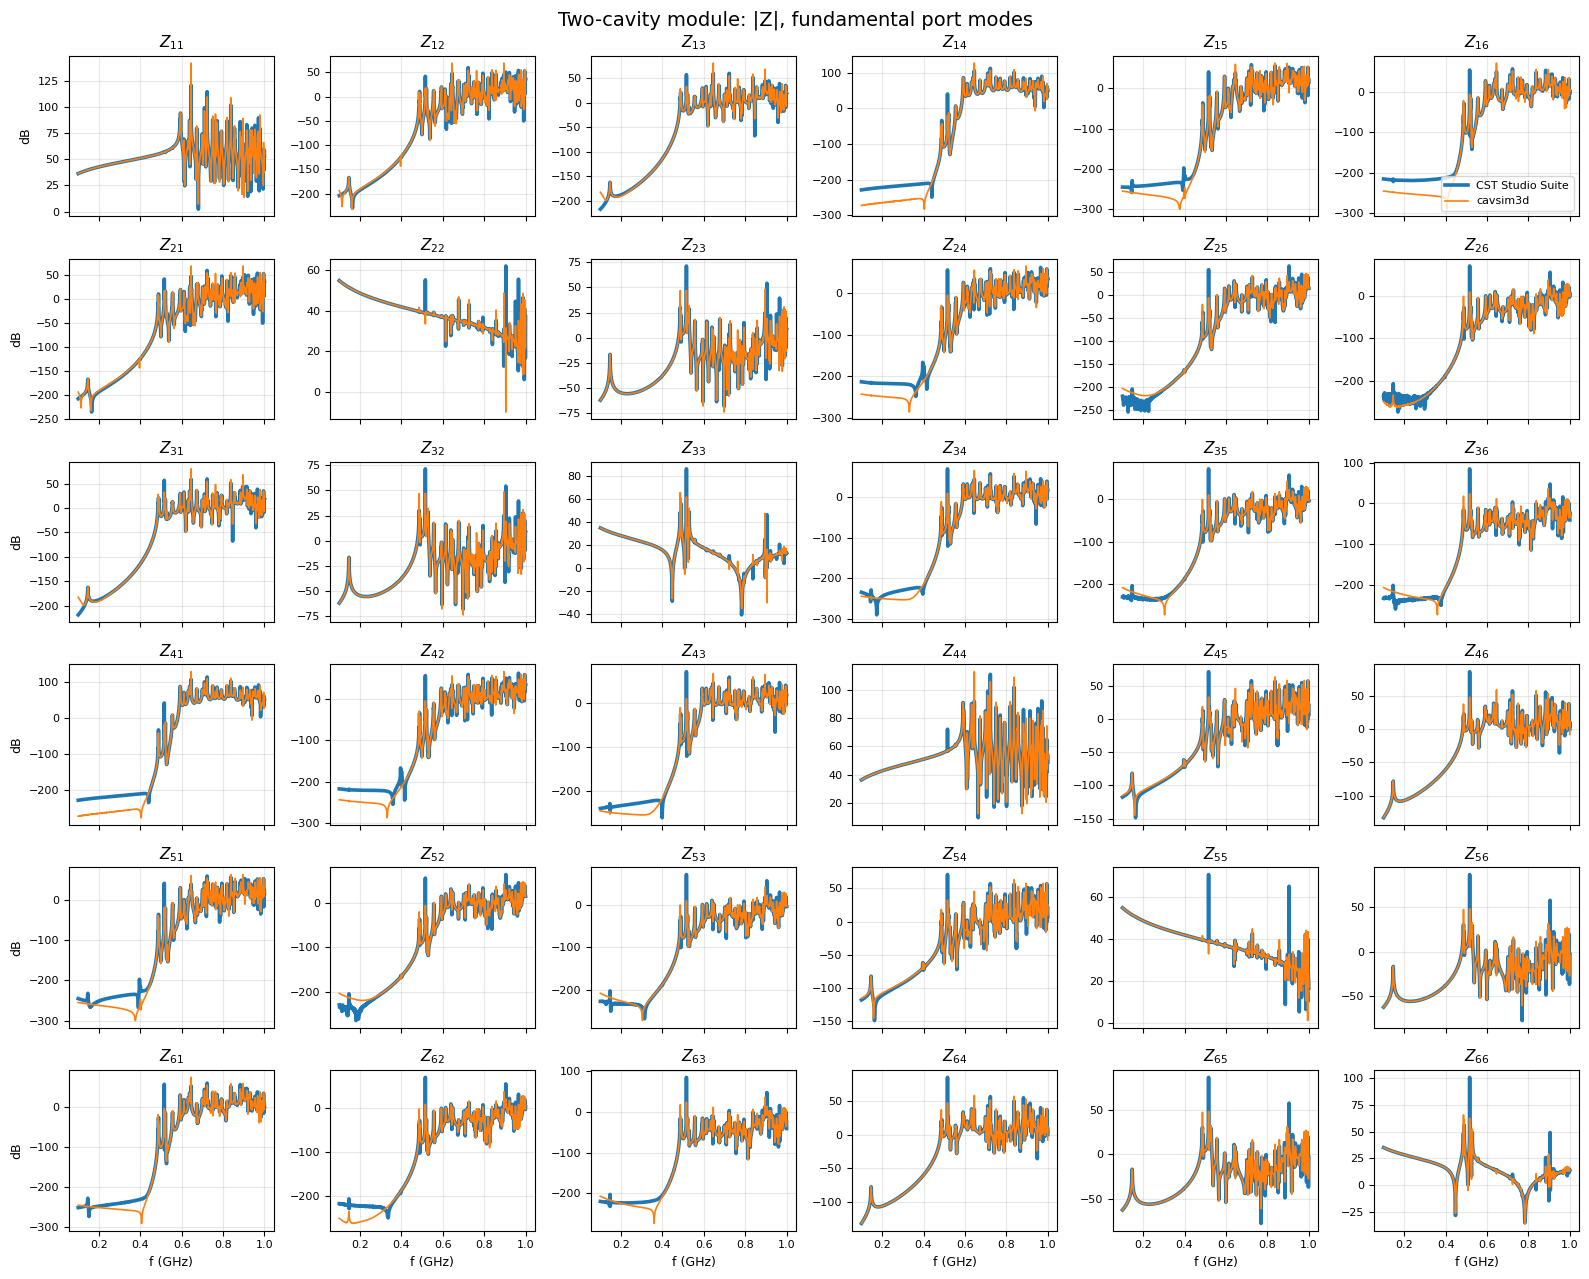

In [7]:
matrix_plot(Z, Z_cst, "Z")

## 6. The other modes at the bottom beam pipe

CST defines the second TE$_{11}$ polarisation and TM$_{01}$ at its bottom port as well, so
these can be compared too.

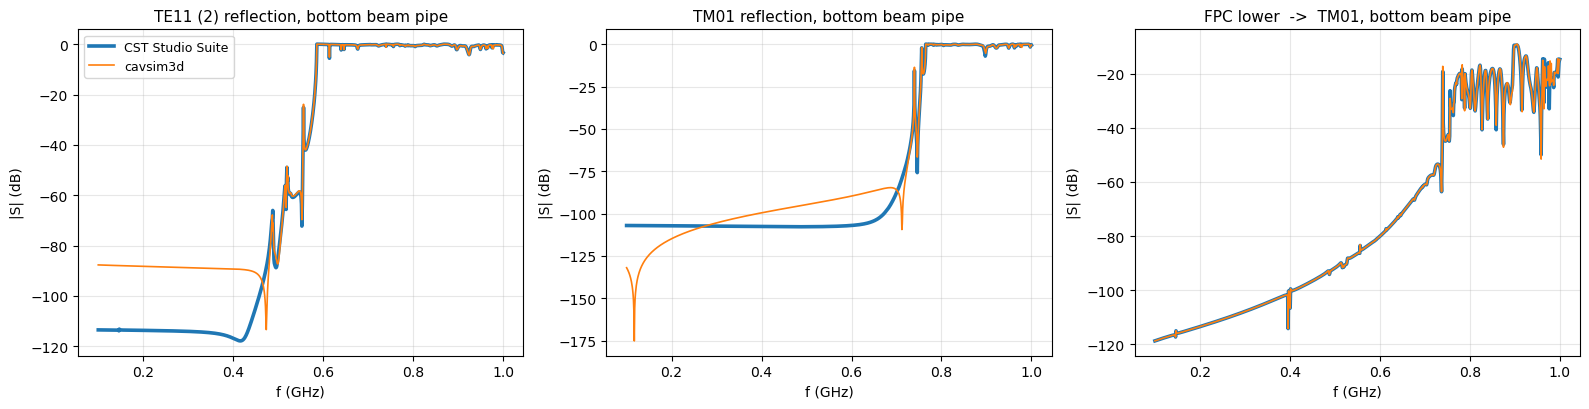

In [8]:
detail_plot([(4, 4, "TE11 (2) reflection, bottom beam pipe"),
             (5, 5, "TM01 reflection, bottom beam pipe"),
             (5, 6, "FPC lower  ->  TM01, bottom beam pipe")], S, S_cst)

## 7. Agreement by frequency band

Mean difference in $|S|$ over the compared entries. The band edges are the beam-pipe cutoffs.

In [9]:
EDGES = [0.1, 0.45, 0.5857, 0.765, 0.9, 0.9715, 1.0]


def band_errors(A, A_ref):
    diff = np.abs(np.abs(A) - np.abs(A_ref))
    return [diff[(freq >= lo) & (freq <= hi)].mean()
            for lo, hi in zip(EDGES[:-1], EDGES[1:])]


def fundamental(A):
    return A[:, MAIN][:, :, MAIN]


table = pd.DataFrame({
    "band (GHz)": [f"{lo:.3f}-{hi:.3f}"
                   for lo, hi in zip(EDGES[:-1], EDGES[1:])],
    "fundamental modes": band_errors(fundamental(S), fundamental(S_cst)),
    "all compared modes": band_errors(S, S_cst),
})
table.style.format({"fundamental modes": "{:.1e}",
                    "all compared modes": "{:.1e}"}).hide(axis="index")

band (GHz),fundamental modes,all compared modes
0.100-0.450,2.4e-06,2.0e-06
0.450-0.586,1.8e-04,1.2e-04
0.586-0.765,5.8e-04,5.0e-04
0.765-0.900,1.6e-03,2.1e-03
0.900-0.972,3.2e-03,3.3e-03
0.972-1.000,7.8e-03,7.7e-03


## 8. Snapshots, model size and cost

The same comparison with 10, 30 and 50 snapshots, and what each stage costs. Times are wall-clock
on the laptop named above.

In [10]:
FMT = {"reduced model (DOFs)": "{:.0f}",
       "coupled system (DOFs)": "{:.0f}",
       "full-order solve (s)": "{:.0f}",
       "reduction (s)": "{:.1f}",
       "coupling (s)": "{:.1f}",
       "1001-point sweep (s)": "{:.2f}",
       "mean |S| difference above 585.7 MHz": "{:.1e}"}
above = freq > 0.5857
columns = {}
for k, ns in enumerate(SAVED["conv_n_samples"].astype(int)):
    diff = np.abs(np.abs(SAVED[f"S_ns{ns}"]) - np.abs(S_cst))[above]
    values = [SAVED["conv_rom_dofs"][k], SAVED["conv_concat_dofs"][k],
              SAVED["conv_t_fom"][k], SAVED["conv_t_rom"][k],
              SAVED["conv_t_build"][k], SAVED["conv_t_sweep"][k],
              diff.mean()]
    columns[f"{ns} snapshots"] = {row: FMT[row].format(v)
                                  for row, v in zip(FMT, values)}
pd.DataFrame(columns)

,10 snapshots,30 snapshots,50 snapshots
reduced model (DOFs),110,166,168
coupled system (DOFs),215,327,331
full-order solve (s),740,1831,2923
reduction (s),23.8,43.3,69.1
coupling (s),2.8,4.9,7.9
1001-point sweep (s),0.78,1.68,1.95
mean |S| difference above 585.7 MHz,2.7e-02,2.1e-03,2.0e-03


With 30 snapshots the reduced model has converged: 50 snapshots add two basis vectors and
change the difference from CST by less than $10^{-4}$. Ten snapshots are too few above about
0.7 GHz, where the cavity's resonances crowd together.

For scale, the CST reference solves the whole module with second-order elements on 1,914,415
tetrahedra (11,896,426 unknowns). Here each cavity has 110,428 tetrahedra (1,135,086
unknowns), solved once; the coupled module has 331 unknowns. A longer chain is built from the
same saved cavity with no further full-order solve.

## 9. Reading the curves below 585.7 MHz

Below the TE$_{11}$ cutoff every beam-pipe mode is evanescent, and the beam-pipe entries
become very small. Three kinds of curve appear there:

- **Coupler to beam pipe** (for example $S_{12}$, $S_{45}$). The field reaches the beam port only
  through the evanescent pipe, so the level depends strongly on how far the coupler is from
  that port: about $-90$ dB for the near cavity, and $-160$ to $-250$ dB for the far one. Both
  codes agree on these to within a few dB.
- **Beam-pipe reflection** ($S_{11}$, $S_{44}$). Physically almost nothing comes back through the
  evanescent pipe. What both codes show is a numerical floor: the small mismatch between the
  evanescent mode on the mesh and the exact mode the port assumes.
- **Beam pipe to beam pipe, or to the far couplers** (flat lines near $-250$ to $-280$ dB). These
  paths cross two cavities below cutoff; the values are around $10^{-13}$ of the $O(1)$ entries,
  below double-precision resolution, and carry no information in either code.

The reflection floor falls as the mesh is refined. For one cavity at 0.3 GHz:

| Mesh size bound | Unknowns | $\lvert S_{11} \rvert$ |
|---|---|---|
| none (0.07–0.3 m elements in the pipe) | 795,459 | $-55$ dB |
| 0.04 m | 935,235 | $-77$ dB |
| 0.03 m | 1,135,086 | $-87$ dB |
| 0.025 m | 1,335,510 | $-90$ dB |

The CST floor likewise depends on its mesh: $-94$ dB in its single-cavity model and $-105$ to
$-117$ dB in the module.

Above the cutoff every entry is well above these floors, and the two codes agree to a few times
$10^{-3}$ in $|S|$.